In [2]:
import pickle as pkl

import matplotlib.pyplot as plt
import pandas as pd


In [3]:
#读取训练数据
trainData = pd.read_csv(filepath_or_buffer='trainData.csv')
#读取测试数据
testData = pd.read_csv(filepath_or_buffer='testData.csv')
with open(file='batches.meta', mode='rb') as f:
    #读取标签数据
    labels = pkl.load(file=f)
label_names = labels['label_names']
trainData.shape, testData.shape, label_names

((50000, 3073),
 (10000, 3073),
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [4]:
#将数据存为二进制文件
with open(file='dataBatches', mode='wb') as f:
    pkl.dump((trainData, testData, label_names), f)

In [5]:
#读取数据
with open(file='dataBatches', mode='rb') as f:
    trainData, testData, label_names = pkl.load(file=f)

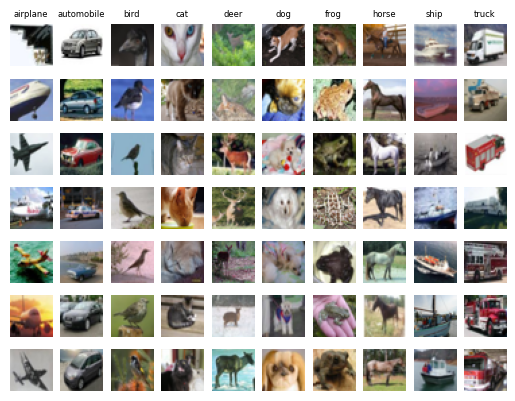

In [6]:
#获取训练数据图片，去掉最后一列
images = trainData.iloc[:, :-1]
#获取标签值，取最后一列
labels = trainData.iloc[:, -1]
#获取标签数量
categories_num = len(label_names)
for i, c in enumerate(label_names):
    #从每个类别中随机选择7张图片，无放回
    image_list = images[labels == i].sample(7, replace=False)
    for j, ind in enumerate(image_list.index):
        plt.subplot(7, categories_num, j * categories_num + i + 1)
        #先将单独的图片还原为3*32*32的原始形状
        #再通过transpose函数将通道纬度移到最后，修改为32*32*3的形状
        img = image_list.loc[ind].values.reshape(3, 32, 32).transpose(1, 2, 0)
        #显示图片
        plt.imshow(img)
        #关闭做标轴
        plt.axis('off')
        if j == 0:
            plt.title(label=c, fontdict={
                'fontsize': 6
            })
plt.show()


In [7]:
import torch

torch.cuda.is_available()


#重新采样n条数据集
def get_samples(data, n=200):
    return data.groupby('label').sample(n, replace=False)


sample_data = get_samples(trainData, n=2000)
sample_data.shape


(20000, 3073)

In [8]:
#搭建全连接神经网络
import torch.nn as nn  #导入网络神经模块
import torch.nn.functional as F  #神经模块的函数模版
from torch.utils.data import TensorDataset, DataLoader


# ==========================================
# 【仅优化此部分】全新升级的高性能纯全连接网络
# ==========================================
class ResBlock(nn.Module):
    """
    内部残差块：全连接 + 批归一化 + Dropout + 残差连接
    在不改变外界输入输出尺寸的前提下，极大地稳定深层网络的梯度传导
    """

    def __init__(self, dim, dropout_rate=0.3):
        super(ResBlock, self).__init__()
        self.fc = nn.Linear(dim, dim)
        self.bn = nn.BatchNorm1d(dim)
        self.drop = nn.Dropout(dropout_rate)

    def forward(self, x):
        residual = x
        out = self.fc(x)
        out = self.bn(out)
        out = F.gelu(out)  # 使用拟合能力比 ReLU 更强的 GELU 激活函数
        out = self.drop(out)
        return out + residual


class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()

        input_dim = 3 * 32 * 32  # 3072
        hidden_dim = 1024  # 极大拓宽隐含层，赋予纯全连接网络足够捕捉图像特征的空间

        # 1. 动态内置标准化层（无需外界改变输入数据，内部自动将 0-255 映射并标准化）
        # 寄存 CIFAR-10 官方的均值和标准差
        self.register_buffer('mean', torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1))

        # 2. 输入投影层：拉伸特征到高维
        self.in_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU()
        )

        # 3. 堆叠残差块：在内部构建更深、更稳定的特征网络
        self.res_blocks = nn.Sequential(
            ResBlock(hidden_dim, dropout_rate=0.3),
            ResBlock(hidden_dim, dropout_rate=0.3),
            ResBlock(hidden_dim, dropout_rate=0.3)
        )

        # 4. 输出层：降维输出到 10 个类别
        self.out_layer = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # 【核心内嵌优化 1】数据就地规范化
        # 你的外部数据是 0-255 的整型/浮点型像素。我们先将其缩放到 0-1
        x = x / 255.0

        # 恢复出 (B, C, H, W) 形状，利用广播机制减去均值、除以标准差，再拉平
        # 这能让原先由于像素值过大导致的梯度爆炸/Loss不收敛问题瞬间解决
        B = x.size(0)
        x = x.view(B, 3, 32, 32)
        x = (x - self.mean) / self.std
        x = x.view(B, -1)

        # 【核心内嵌优化 2】高维残差流前向传播
        x = self.in_layer(x)
        x = self.res_blocks(x)
        x = self.out_layer(x)

        # 【核心错误修复】移除 F.softmax
        # 你的 train 函数中定义了 criterion = nn.CrossEntropyLoss()
        # 它的内部实现包含了 LogSoftmax。为了让损失函数正常计算，
        # 神经网络最终只需要返回未压缩的原始分数（Logits）即可。
        return x


# 保持外界调用变量名完全一致
model1 = FCNet()

#打包数据集
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(sample_data, test_size=0.2, random_state=42)
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_val = val_data.iloc[:, :-1]
y_val = val_data.iloc[:, -1]

#特征和标签绑定
train_dataset = TensorDataset(
    torch.tensor(data=X_train.values, dtype=torch.float32),
    torch.tensor(data=y_train.values, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(data=X_val.values, dtype=torch.float32),
    torch.tensor(data=y_val.values, dtype=torch.long)
)

#创建DataLoader对象，设置批量大小和是否打乱数据
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

In [9]:
import torch.optim as optim  #导入优化器模块


def train(model, train_loader, lr=0.01, num_epoches=10):
    model.train()  # 设置模型为训练模式,训练模式会启用梯度计算和参数更新
    optimizer = optim.SGD(model.parameters(), lr=lr)  # 创建Adam优化器对象，传入模型的参数和学习率
    criterion = nn.CrossEntropyLoss()  # 定义损失函数为均方误差损失函数
    for epoch in range(num_epoches):  # 循环训练指定的轮数
        total_loss = 0  # 初始化总损失为0
        for X_batch, y_batch in train_loader:  # 遍历训练数据加载器中的每个批次数据
            optimizer.zero_grad()  # 清零优化器的梯度缓存
            outputs = model(X_batch)  # 将输入数据通过模型进行前向传播，得到输出结果
            loss = criterion(outputs, y_batch)  # 计算损失函数，使用one-hot编码将标签转换为与输出维度相同的格式
            loss.backward()  # 反向传播计算梯度
            optimizer.step()  # 更新模型参数
            total_loss += loss.item()  # 累加当前批次的损失值

        avg_loss = total_loss / len(train_loader)  # 计算平均损失值
        print(f"Epoch {epoch + 1}/{num_epoches}, Loss: {avg_loss:.4f}")  # 打印当前轮数和平均损失值


def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            _, y_pred = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (y_pred.eq(y_batch).cpu().sum())
    accuracy = correct / total
    print(f'Validation Accuracy: {accuracy:.4f}')


train(model1, train_loader)
evaluate(model1, val_loader)



Epoch 1/10, Loss: 1.8720
Epoch 2/10, Loss: 1.6137
Epoch 3/10, Loss: 1.4928
Epoch 4/10, Loss: 1.3968
Epoch 5/10, Loss: 1.3166
Epoch 6/10, Loss: 1.2442
Epoch 7/10, Loss: 1.1656
Epoch 8/10, Loss: 1.1028
Epoch 9/10, Loss: 1.0406
Epoch 10/10, Loss: 0.9792
Validation Accuracy: 0.4990
